# EDA

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
#users = pd.read_csv('raw_data/users.csv')
#fligths = pd.read_csv('raw_data/flights.csv')
#hotels = pd.read_csv('raw_data/hotels.csv')
sessions = pd.read_csv('raw_data/sessions.csv')

# Sessions

In [3]:
sessions

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
0,676570-f883c6e630f641cd9ca5ac61ae7045d5,676570,676570-ed23a4a861404b84b240ca68b9da1cb3,2023-03-27 19:37:00,2023-03-27 19:49:41,False,False,NaN,NaN,True,True,103,False
1,676707-f6b681d65ce44f4a9e895ad407ce3c79,676707,NaN,2023-03-27 19:05:00,2023-03-27 19:05:40,False,False,NaN,NaN,False,False,6,False
2,682247-ee2ef33c4dc6460fb15776d11f4a3cae,682247,NaN,2023-03-27 16:40:00,2023-03-27 16:40:45,False,False,NaN,NaN,False,False,6,False
3,684521-8e79dc4b20f24aecaea55a8084fbe4be,684521,NaN,2023-03-27 12:25:00,2023-03-27 12:26:19,False,False,NaN,NaN,False,False,11,False
4,684764-59c801395dec4aea939559ff4550bb34,684764,684764-584ca496c5ed4faca39b4fa85992c3c4,2023-03-27 04:23:00,2023-03-27 04:25:10,True,False,0.15,NaN,True,True,18,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48678,646455-e5ce3d55158a48d8afe821275001db38,646455,646455-1ed122d378a54ab69178c09405415dab,2023-03-27 18:17:00,2023-03-27 18:19:15,False,False,NaN,NaN,True,True,18,False
48679,656708-852b56ed84124df09fb6ddaf9b7fa2b3,656708,NaN,2023-03-27 20:07:00,2023-03-27 20:09:23,False,False,NaN,NaN,False,False,19,False
48680,659161-16f953ffd8304522a9a6372e844a7609,659161,659161-ec1633bb2b374247b9b93692a39ffbc6,2023-03-27 16:06:00,2023-03-27 16:09:34,False,False,NaN,NaN,True,True,29,False
48681,662750-7e4c81aca2fa4e2db2f4b96fad442b0e,662750,NaN,2023-03-27 13:45:00,2023-03-27 13:46:15,True,True,0.05,0.2,False,False,10,False


In [4]:
sessions.info()

<class 'pandas.DataFrame'>
RangeIndex: 48683 entries, 0 to 48682
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   session_id              48683 non-null  str    
 1   user_id                 48683 non-null  int64  
 2   trip_id                 16778 non-null  str    
 3   session_start           48683 non-null  str    
 4   session_end             48683 non-null  str    
 5   flight_discount         48683 non-null  bool   
 6   hotel_discount          48683 non-null  bool   
 7   flight_discount_amount  8170 non-null   float64
 8   hotel_discount_amount   6183 non-null   float64
 9   flight_booked           48683 non-null  bool   
 10  hotel_booked            48683 non-null  bool   
 11  page_clicks             48683 non-null  int64  
 12  cancellation            48683 non-null  bool   
dtypes: bool(5), float64(2), int64(2), str(4)
memory usage: 3.2 MB


- discount columns has nan values, we can fill them.
- flight hotel discount überflüssig

In [15]:
sessions

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
0,676570-f883c6e630f641cd9ca5ac61ae7045d5,676570,676570-ed23a4a861404b84b240ca68b9da1cb3,2023-03-27 19:37:00,2023-03-27 19:49:41,False,False,NaN,NaN,True,True,103,False
1,676707-f6b681d65ce44f4a9e895ad407ce3c79,676707,NaN,2023-03-27 19:05:00,2023-03-27 19:05:40,False,False,NaN,NaN,False,False,6,False
2,682247-ee2ef33c4dc6460fb15776d11f4a3cae,682247,NaN,2023-03-27 16:40:00,2023-03-27 16:40:45,False,False,NaN,NaN,False,False,6,False
3,684521-8e79dc4b20f24aecaea55a8084fbe4be,684521,NaN,2023-03-27 12:25:00,2023-03-27 12:26:19,False,False,NaN,NaN,False,False,11,False
4,684764-59c801395dec4aea939559ff4550bb34,684764,684764-584ca496c5ed4faca39b4fa85992c3c4,2023-03-27 04:23:00,2023-03-27 04:25:10,True,False,0.15,NaN,True,True,18,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48678,646455-e5ce3d55158a48d8afe821275001db38,646455,646455-1ed122d378a54ab69178c09405415dab,2023-03-27 18:17:00,2023-03-27 18:19:15,False,False,NaN,NaN,True,True,18,False
48679,656708-852b56ed84124df09fb6ddaf9b7fa2b3,656708,NaN,2023-03-27 20:07:00,2023-03-27 20:09:23,False,False,NaN,NaN,False,False,19,False
48680,659161-16f953ffd8304522a9a6372e844a7609,659161,659161-ec1633bb2b374247b9b93692a39ffbc6,2023-03-27 16:06:00,2023-03-27 16:09:34,False,False,NaN,NaN,True,True,29,False
48681,662750-7e4c81aca2fa4e2db2f4b96fad442b0e,662750,NaN,2023-03-27 13:45:00,2023-03-27 13:46:15,True,True,0.05,0.2,False,False,10,False


In [63]:
sessions[~(~sessions[["flight_discount_amount", "hotel_discount_amount"]].isna().values == sessions[["flight_discount", "hotel_discount"]].values).all(axis=1)]

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
8476,101486-46912e06b8f94b949f46af20eb097f8f,101486,101486-29a51199b1a748da8c45d3d2fc9c691a,2022-03-26 20:08:22,2022-03-26 22:08:22,True,True,NaN,NaN,True,True,156,True
8477,118043-e476985728a741d7a96ea1dcf55963e6,118043,118043-2c1b2e17eb1147e184b00be13725d0fd,2022-04-22 09:38:27,2022-04-22 10:04:44.411729,True,True,NaN,NaN,True,True,26,True
8478,153982-0a2c4b9c37594cca8019068acedd878a,153982,153982-5ee3beaabece462ba68982ef4f8e3a23,2022-07-08 13:15:40,2022-07-08 14:20:35.612564,True,True,NaN,NaN,True,True,64,True
8479,174997-d37e4081489646fc891296f5e21b96f1,174997,174997-a7c3a96620594e849a2345ac4e0bd45d,2023-01-05 20:17:50,2023-01-05 22:17:50,True,True,NaN,NaN,True,True,155,True
8480,181157-4689176bf8e2444f928c77739c75c713,181157,181157-259acaefcd924050bd6640f049eded1a,2022-05-23 20:16:04,2022-05-23 22:16:04,True,True,NaN,NaN,True,True,200,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33126,694265-74b2a86e73854afea04cd84b1a1d10e3,694265,694265-442d6499b511481786add276f620d4fc,2023-07-26 21:37:49,2023-07-26 22:30:14.467636,True,True,NaN,NaN,True,True,52,True
33127,589228-c82de5b13d8d4739aeb90e2ca924d2e0,589228,589228-7cbd8bd73eed4c549a0074919e71fdc8,2023-07-20 21:01:17,2023-07-20 21:45:04.905844,True,True,NaN,NaN,True,True,43,True
33128,671151-fa865fb0bf8249aeb164408b470322d2,671151,671151-a25acb9062764a168fbd4286d15d57fd,2023-07-24 17:45:47,2023-07-24 18:09:14.839854,True,True,NaN,NaN,True,True,23,True
33129,609393-17fa2042385e48faac6ab20586749340,609393,609393-b92d487037ec447db1e3ddf977709a52,2023-07-21 21:02:05,2023-07-21 21:27:18.179946,True,True,NaN,NaN,True,True,25,True


In [55]:
sessions[["flight_discount", "hotel_discount"]]

,flight_discount,hotel_discount
0,False,False
1,False,False
2,False,False
3,False,False
4,True,False
...,...,...
48678,False,False
48679,False,False
48680,False,False
48681,True,True


In [53]:
~(~sessions[["flight_discount_amount", "hotel_discount_amount"]].isna().values == sessions[["flight_discount", "hotel_discount"]].values).all(axis=1)

array([False, False, False, ..., False, False, False], shape=(48683,))

In [52]:
sessions[~(~sessions[["flight_discount_amount", "hotel_discount_amount"]].isna().values == sessions[["flight_discount", "hotel_discount"]].values).all(axis=1)]

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
8476,101486-46912e06b8f94b949f46af20eb097f8f,101486,101486-29a51199b1a748da8c45d3d2fc9c691a,2022-03-26 20:08:22,2022-03-26 22:08:22,True,True,NaN,NaN,True,True,156,True
8477,118043-e476985728a741d7a96ea1dcf55963e6,118043,118043-2c1b2e17eb1147e184b00be13725d0fd,2022-04-22 09:38:27,2022-04-22 10:04:44.411729,True,True,NaN,NaN,True,True,26,True
8478,153982-0a2c4b9c37594cca8019068acedd878a,153982,153982-5ee3beaabece462ba68982ef4f8e3a23,2022-07-08 13:15:40,2022-07-08 14:20:35.612564,True,True,NaN,NaN,True,True,64,True
8479,174997-d37e4081489646fc891296f5e21b96f1,174997,174997-a7c3a96620594e849a2345ac4e0bd45d,2023-01-05 20:17:50,2023-01-05 22:17:50,True,True,NaN,NaN,True,True,155,True
8480,181157-4689176bf8e2444f928c77739c75c713,181157,181157-259acaefcd924050bd6640f049eded1a,2022-05-23 20:16:04,2022-05-23 22:16:04,True,True,NaN,NaN,True,True,200,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33126,694265-74b2a86e73854afea04cd84b1a1d10e3,694265,694265-442d6499b511481786add276f620d4fc,2023-07-26 21:37:49,2023-07-26 22:30:14.467636,True,True,NaN,NaN,True,True,52,True
33127,589228-c82de5b13d8d4739aeb90e2ca924d2e0,589228,589228-7cbd8bd73eed4c549a0074919e71fdc8,2023-07-20 21:01:17,2023-07-20 21:45:04.905844,True,True,NaN,NaN,True,True,43,True
33128,671151-fa865fb0bf8249aeb164408b470322d2,671151,671151-a25acb9062764a168fbd4286d15d57fd,2023-07-24 17:45:47,2023-07-24 18:09:14.839854,True,True,NaN,NaN,True,True,23,True
33129,609393-17fa2042385e48faac6ab20586749340,609393,609393-b92d487037ec447db1e3ddf977709a52,2023-07-21 21:02:05,2023-07-21 21:27:18.179946,True,True,NaN,NaN,True,True,25,True


In [40]:
sessions[~(~sessions[["flight_discount_amount", "hotel_discount_amount"]].isna().values == sessions[["flight_discount", "hotel_discount"]].values).all(axis=1)][["flight_discount", "hotel_discount", "flight_discount_amount", "hotel_discount_amount"]].drop_duplicates()

,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount
8476,True,True,NaN,NaN


In [49]:
sessions[["flight_discount_amount", "hotel_discount_amount"]].mean()

flight_discount_amount    0.139553
hotel_discount_amount     0.112065
dtype: float64

We are thinking on dropping the discount columns, since they are redundant. We wanted to proof the redundancy and found out that there is a discrepancy in the data. The discount columns are not always consistent with the discount amount columns. Never the less the only error are of the kind [True , True] -> [nan, nan]. We will substitue this ones with the mistakes with mean. # TODO: substitute the values with mean and drop the discount columns adn drop the discount columns

In [42]:
sessions[["flight_discount_amount", "hotel_discount_amount"]].count()

flight_discount_amount    8170
hotel_discount_amount     6183
dtype: int64

<Axes: >

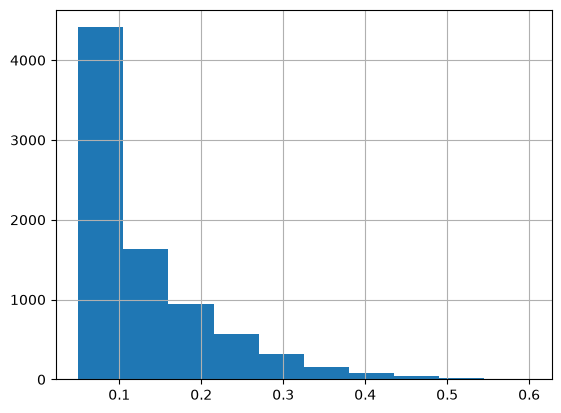

In [47]:
sessions["flight_discount_amount"].hist()

<Axes: >

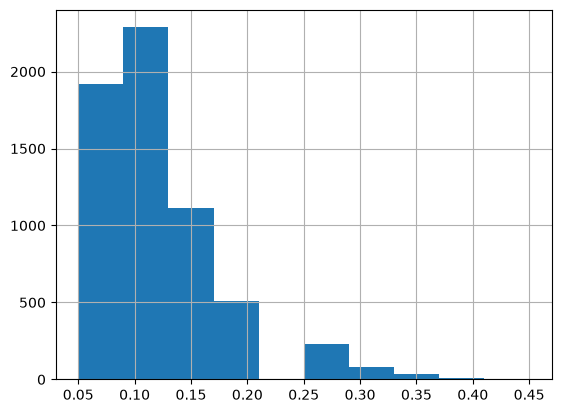

In [48]:
sessions["hotel_discount_amount"].hist()